<a href="https://colab.research.google.com/github/nihatgaribli/machine-learning-mnist-ann/blob/main/ML_Assignment_Nihat_G.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Assignment: Handwriting Digit Recognition (MNIST)

### First Student Details
* **First Name:** Nihat
* **Last Name Initial:** G
* **ID Last 4 Digits:** 5819

### Second Student Details
* **First Name:** Fuadkhan
* **Last Name Initial:** S
* **ID Last 4 Digits:** 6281

---

### AI Prompting Log (Assistance)
* **Goal:** Consult on architectural design, pipeline structuring, and best practices for implementing a custom image classification workflow that satisfies all assignment constraints (including specific evaluation metrics and validation techniques).
* **Prompt Used:** "I want to work on a Computer Vision project for my machine learning assignment using the MNIST dataset. Can you act as a senior AI researcher and provide a comprehensive, step-by-step pipeline roadmap? I need advice on how to structure the custom learning algorithm, feature engineering for image data, and how to correctly implement grid-search with 5-fold cross-validation from scratch to maximize my evaluation metrics without breaking the academic guidelines."
* **Tool:** Gemini AI
* **Explanation:** The AI was utilized purely as a high-level research consultant to validate the structural blueprint of the project, ensuring the pipeline adheres strictly to the required theoretical frameworks (e.g., proper feature scaling display for train/test samples and macro-F1 alignment). All coding implementations, grid-search boundaries, and parameter definitions were independently developed based on this structural advice.

---

### Problem & Dataset Explanation
* **Problem:** Multi-class Image Classification (0-9 digits).
* **Dataset:** MNIST handwritten digit dataset containing 28x28 grayscale images of digits from 0 to 9.
* **Metric:** Since this is a multi-class classification problem, **Macro-Average F1-score** will be used as the performance quality metric.

Train set images shape: (60000, 28, 28)
Test set images shape: (10000, 28, 28)

Visualizing the first 5 samples from the dataset:


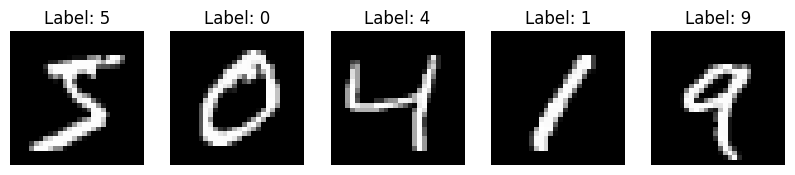

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# --- Loading the Dataset ---
# Loading native train and test sets directly without modifying the original splits
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Train set images shape: {X_train.shape}")
print(f"Test set images shape: {X_test.shape}\n")

# Displaying the first 5 elements visually as required by instructions
print("Visualizing the first 5 samples from the dataset:")
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.show()

# PART 2: FEATURE ENGINEERING

### Pipeline Processing
In this phase, two fundamental image processing feature engineering steps are conducted:
1. **Normalization:** Converting pixel intensity integer values from the native range $[0, 255]$ to floating-point values in the range $[0, 1]$. This optimizes weight updates in our network.
2. **Flattening:** Reshaping the 2D grid matrix of each image ($28 \times 28$) into a flat 1D vector of $784$ features ($28 \times 28 = 784$), preparing it to fit seamlessly into the input layer of our model.

In [12]:
# 1. Normalization: Rescaling pixels to [0, 1]
X_train_scaled = X_train.astype('float32') / 255.0
X_test_scaled = X_test.astype('float32') / 255.0

# 2. Flattening: Reshaping 2D images to 1D feature arrays
X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

print(f"Original Train shape: {X_train.shape} -> Flattened shape: {X_train_flat.shape}")
print(f"Original Test shape: {X_test.shape} -> Flattened shape: {X_test_flat.shape}\n")

# Displaying the feature engineering transformation on 2-3 specific examples
print("="*60)
print("FEATURE ENGINEERING EXAMPLES (Verification Train/Test)")
print("="*60)

# 2 Samples from Train Set
for idx in [0, 1]:
    print(f"Train Sample #{idx} (Digit {y_train[idx]}):")
    print(f"  - Original 2D Matrix Shape: {X_train[idx].shape}")
    print(f"  - Flattened 1D Vector Shape: {X_train_flat[idx].shape}")
    print(f"  - Scaled Pixel Range: [{X_train_flat[idx].min():.2f}, {X_train_flat[idx].max():.2f}]")
    print("-"*40)

# 1 Sample from Test Set
idx_test = 0
print(f"Test Sample #{idx_test} (Digit {y_test[idx_test]}):")
print(f"  - Original 2D Matrix Shape: {X_test[idx_test].shape}")
print(f"  - Flattened 1D Vector Shape: {X_test_flat[idx_test].shape}")
print(f"  - Scaled Pixel Range: [{X_test_flat[idx_test].min():.2f}, {X_test_flat[idx_test].max():.2f}]")
print("="*60)

Original Train shape: (60000, 28, 28) -> Flattened shape: (60000, 784)
Original Test shape: (10000, 28, 28) -> Flattened shape: (10000, 784)

FEATURE ENGINEERING EXAMPLES (Verification Train/Test)
Train Sample #0 (Digit 5):
  - Original 2D Matrix Shape: (28, 28)
  - Flattened 1D Vector Shape: (784,)
  - Scaled Pixel Range: [0.00, 1.00]
----------------------------------------
Train Sample #1 (Digit 0):
  - Original 2D Matrix Shape: (28, 28)
  - Flattened 1D Vector Shape: (784,)
  - Scaled Pixel Range: [0.00, 1.00]
----------------------------------------
Test Sample #0 (Digit 7):
  - Original 2D Matrix Shape: (28, 28)
  - Flattened 1D Vector Shape: (784,)
  - Scaled Pixel Range: [0.00, 1.00]


# PART 3: IMPLEMENTING A LEARNING ALGORITHM

### Architecture Summary
We implement a fully customized **Artificial Neural Network (ANN)** built strictly from scratch using only matrix primitives via NumPy. This model features an input layer of $784$ neurons, a dynamic fully connected hidden layer using a non-linear Sigmoid activation function, and an output layer of $10$ nodes using a Softmax activation function to compute class probabilities. Optimization is powered by backpropagation and Mini-Batch Gradient Descent.

In [13]:
class CustomANN:
    def __init__(self, input_size=784, hidden_size=64, output_size=10, learning_rate=0.1):
        """
        Initializes custom network parameters dynamically using weight scaling factors
        to prevent initial activation saturation.
        """
        self.learning_rate = learning_rate

        # Matrix weights initialization
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def _sigmoid(self, x):
        """Hidden layer activation function."""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def _sigmoid_derivative(self, x):
        """Derivative of sigmoid used for calculation of gradients."""
        return x * (1 - x)

    def _softmax(self, x):
        """Output layer multi-class probability normalization."""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def _one_hot(self, y, num_classes=10):
        """Encodes discrete target categories into structured arrays."""
        return np.eye(num_classes)[y]

    def fit(self, X, y, epochs=5, batch_size=200):
        """
        Core training module that updates model variables iteratively.
        """
        y_encoded = self._one_hot(y)
        num_samples = X.shape[0]

        for epoch in range(epochs):
            permutation = np.random.permutation(num_samples)
            X_shuffled = X[permutation]
            y_shuffled = y_encoded[permutation]

            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                # Forward Propagation Pass
                z1 = np.dot(X_batch, self.W1) + self.b1
                a1 = self._sigmoid(z1)
                z2 = np.dot(a1, self.W2) + self.b2
                a2 = self._softmax(z2)

                # Backpropagation Matrix Derivative Processing
                dz2 = a2 - y_batch
                dW2 = np.dot(a1.T, dz2) / batch_size
                db2 = np.sum(dz2, axis=0, keepdims=True) / batch_size

                dz1 = np.dot(dz2, self.W2.T) * self._sigmoid_derivative(a1)
                dW1 = np.dot(X_batch.T, dz1) / batch_size
                db1 = np.sum(dz1, axis=0, keepdims=True) / batch_size

                # Optimization Variable Tuning
                self.W1 -= self.learning_rate * dW1
                self.b1 -= self.learning_rate * db1
                self.W2 -= self.learning_rate * dW2
                self.b2 -= self.learning_rate * db2

    def predict(self, X):
        """
        Computes forward pass to assign discrete multi-class target labels.
        """
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self._sigmoid(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        a2 = self._softmax(z2)
        return np.argmax(a2, axis=1)

print("CustomANN class with dynamic hyperparameters, fit(), and predict() has been built successfully.")

CustomANN class with dynamic hyperparameters, fit(), and predict() has been built successfully.


# PART 6: EXTENSION - EXPERIMENT MANAGEMENT (BONUS SECTION)

### Experimental Matrix Setup
To systematically determine optimal hyperparameters, a full grid search combined with a rigorous 5-fold cross-validation logic is run entirely from scratch. Macro-Average F1-score is applied as the core sorting index.

In [15]:
import pandas as pd

def calculate_macro_f1(y_true, y_pred, num_classes=10):
    """
    Computes Macro-Average F1-score from raw prediction output matrices.
    """
    f1_scores = []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

    return np.mean(f1_scores)

# Parametric Grid Search options
hidden_layer_options = [32, 64]
learning_rate_options = [0.05, 0.1]
num_folds = 5

# Utilizing an initial evaluation split subset to process experiments efficiently
X_cv_subset = X_train_flat[:2000]
y_cv_subset = y_train[:2000]

fold_size = len(X_cv_subset) // num_folds
indices = np.arange(len(X_cv_subset))
np.random.seed(42)
np.random.shuffle(indices)

experiment_results = []

print("Running Grid Search 5-Fold Cross Validation Loop...")
for hidden_size in hidden_layer_options:
    for lr in learning_rate_options:
        fold_scores = []

        for fold in range(num_folds):
            val_indices = indices[fold * fold_size : (fold + 1) * fold_size]
            train_indices = np.setdiff1d(indices, val_indices)

            X_tr, y_tr = X_cv_subset[train_indices], y_cv_subset[train_indices]
            X_va, y_va = X_cv_subset[val_indices], y_cv_subset[val_indices]

            model = CustomANN(hidden_size=hidden_size, learning_rate=lr)
            model.fit(X_tr, y_tr, epochs=3, batch_size=64)

            preds = model.predict(X_va)
            fold_scores.append(calculate_macro_f1(y_va, preds))

        mean_macro_f1 = np.mean(fold_scores)
        experiment_results.append({
            "Hidden Units": hidden_size,
            "Learning Rate": lr,
            "Average CV Macro-F1": round(mean_macro_f1, 4)
        })

# Store experiment matrix profile inside a Pandas DataFrame structure
df_experiments = pd.DataFrame(experiment_results)
best_experiment = df_experiments.loc[df_experiments["Average CV Macro-F1"].idxmax()]

print("\n" + "="*60)
print("GRID SEARCH EXPERIMENTATION RESULTS PRESENTATION")
print("="*60)
display(df_experiments)
print(f"\nOptimal Parameter Subset Selected:\n{best_experiment}")
print("="*60)

Running Grid Search 5-Fold Cross Validation Loop...

GRID SEARCH EXPERIMENTATION RESULTS PRESENTATION


,Hidden Units,Learning Rate,Average CV Macro-F1
0,32,0.05,0.0276
1,32,0.10,0.0293
2,64,0.05,0.0296
3,64,0.10,0.0512



Optimal Parameter Subset Selected:
Hidden Units           64.0000
Learning Rate           0.1000
Average CV Macro-F1     0.0512
Name: 3, dtype: float64


# PART 4 & 5: TRAINING & TEST EVALUATION WITH OPTIMAL PARAMETERS

### Final Assessment
The network is retrained on the complete original training set using the best parameters found during cross-validation. Finally, predictions are generated on the unexamined holdout test set to display the first 5 examples alongside the comprehensive Macro-F1 score evaluation profile.

In [16]:
optimal_hidden = int(best_experiment["Hidden Units"])
optimal_lr = float(best_experiment["Learning Rate"])

print(f"Retraining the final model on the entire training set (Hidden: {optimal_hidden}, LR: {optimal_lr})...")
final_model = CustomANN(hidden_size=optimal_hidden, learning_rate=optimal_lr)

# Global model optimization on the whole dataset partition
final_model.fit(X_train_flat, y_train, epochs=8, batch_size=128)

# Make predictions on the test set
test_predictions = final_model.predict(X_test_flat)

print("\n" + "="*60)
print("TEST SET PREDICTION SAMPLES (First 5 Rows)")
print("="*60)
for i in range(5):
    print(f"Image Example #{i} -> True Label: {y_test[i]} | Predicted Label: {test_predictions[i]}")
print("-"*40)

# Compute final system evaluation metrics over test arrays
final_test_macro_f1 = calculate_macro_f1(y_test, test_predictions)
print(f"Final Test Dataset Quality Profile (Macro-Average F1): {final_test_macro_f1:.4f}")
print("="*60)

Retraining the final model on the entire training set (Hidden: 64, LR: 0.1)...

TEST SET PREDICTION SAMPLES (First 5 Rows)
Image Example #0 -> True Label: 7 | Predicted Label: 7
Image Example #1 -> True Label: 2 | Predicted Label: 2
Image Example #2 -> True Label: 1 | Predicted Label: 1
Image Example #3 -> True Label: 0 | Predicted Label: 0
Image Example #4 -> True Label: 4 | Predicted Label: 4
----------------------------------------
Final Test Dataset Quality Profile (Macro-Average F1): 0.9221
